## **IMPORT CÁC THƯ VIỆN**

In [24]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

## **TẢI DỮ LIỆU**

In [3]:
# Tải và đọc bộ dữ liệu
df = pd.read_excel('/content/dropout_dataset_final.xlsx')
df.head()

,learner_id,gender,learning_mode,device_type,login_frequency,resource_access_count,avg_session_duration,forum_participation,assignment_completion_rate,quiz_completion_rate,inactivity_period,avg_quiz_score,late_submission_rate,age,employment_status,learning_pattern,dropout
0,H0001,Male,Self-study,Tablet,7.448474,29,75.592809,7,70.980378,87.002316,25,76.474338,2.330537,49,1,0,0
1,H0002,Female,Self-study,Mobile phone,15.798234,12,94.330348,18,89.254519,1.954311,18,61.269420,1.964830,27,2,1,0
2,H0003,Male,Group-based learning,Tablet,0.786390,14,95.988471,9,69.078629,41.999831,19,8.073264,43.684065,51,2,1,1
3,H0004,Male,Self-study,Tablet,8.635351,19,102.121509,32,41.662303,96.041406,26,11.858173,92.420582,22,0,1,1
4,H0005,Male,Group-based learning,Mobile phone,7.645118,33,31.999654,36,51.366122,17.716174,22,48.119323,76.811934,37,0,1,1


## **THỐNG KÊ CƠ BẢN**

In [4]:
print("Kiểm tra thông tin dữ liệu:")
print(df.info())

Kiểm tra thông tin dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   learner_id                  9000 non-null   object 
 1   gender                      9000 non-null   object 
 2   learning_mode               9000 non-null   object 
 3   device_type                 9000 non-null   object 
 4   login_frequency             9000 non-null   float64
 5   resource_access_count       9000 non-null   int64  
 6   avg_session_duration        9000 non-null   float64
 7   forum_participation         9000 non-null   int64  
 8   assignment_completion_rate  9000 non-null   float64
 9   quiz_completion_rate        9000 non-null   float64
 10  inactivity_period           9000 non-null   int64  
 11  avg_quiz_score              9000 non-null   float64
 12  late_submission_rate        9000 non-null   float64
 13  age  

## **LÀM SẠCH DỮ LIỆU**

In [5]:
# Xóa cột id không cần thiết
df = df.drop(columns=['learner_id'])

In [6]:
# Kiểm tra giá trị thiếu
print("\nKiểm tra giá trị thiếu:")
print(df.isnull().sum())


Kiểm tra giá trị thiếu:
gender                        0
learning_mode                 0
device_type                   0
login_frequency               0
resource_access_count         0
avg_session_duration          0
forum_participation           0
assignment_completion_rate    0
quiz_completion_rate          0
inactivity_period             0
avg_quiz_score                0
late_submission_rate          0
age                           0
employment_status             0
learning_pattern              0
dropout                       0
dtype: int64


In [7]:
# Kiểm tra dữ liệu trùng lặp
duplicate_count = df.duplicated().sum()
print(f"Số dòng bị trùng lặp: {duplicate_count}")

Số dòng bị trùng lặp: 0


## **XỬ LÝ CÁC GIÁ TRỊ NGOẠI LAI**

In [8]:
# Chọn các cột số
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
numerical_cols = numerical_cols.drop('dropout')
print("Các cột số:")
print(numerical_cols)

Các cột số:
Index(['login_frequency', 'resource_access_count', 'avg_session_duration',
       'forum_participation', 'assignment_completion_rate',
       'quiz_completion_rate', 'inactivity_period', 'avg_quiz_score',
       'late_submission_rate', 'age', 'employment_status', 'learning_pattern'],
      dtype='object')


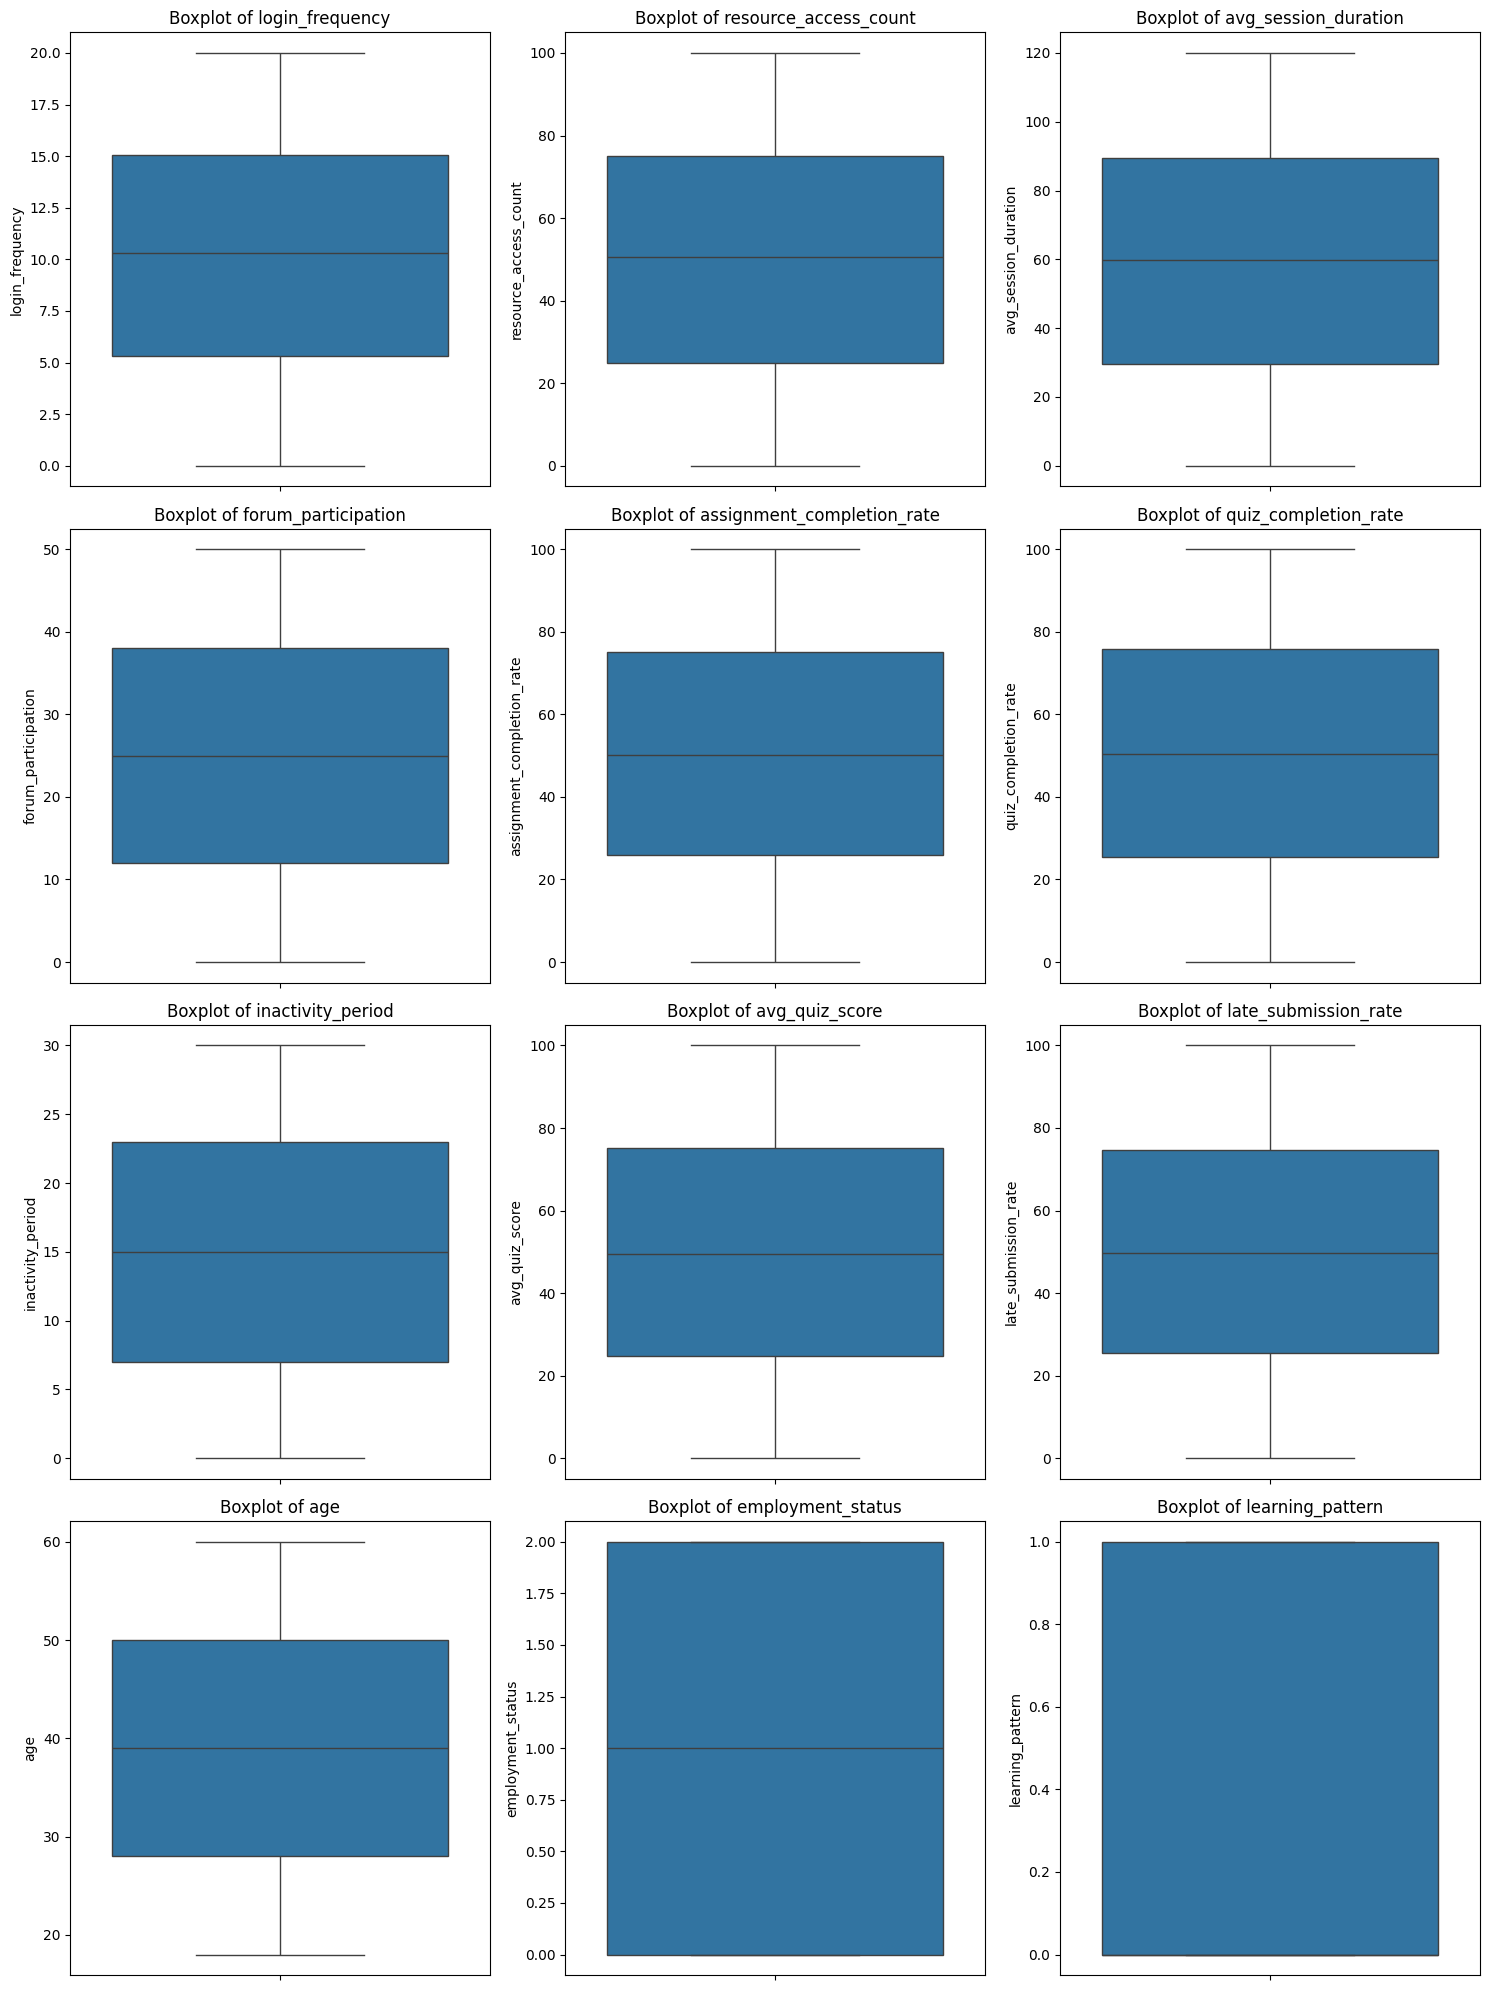

In [9]:
# Thiết lập kích thước và bố cục subplot
n_cols = 3
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols
plt.figure(figsize=(15, 5 * n_rows))
# Vẽ boxplot cho từng cột số
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)

# Hiển thị biểu đồ
plt.tight_layout()
plt.show()

## **KIỂM TRA PHÂN PHỐI CÁC BIẾN SỐ**

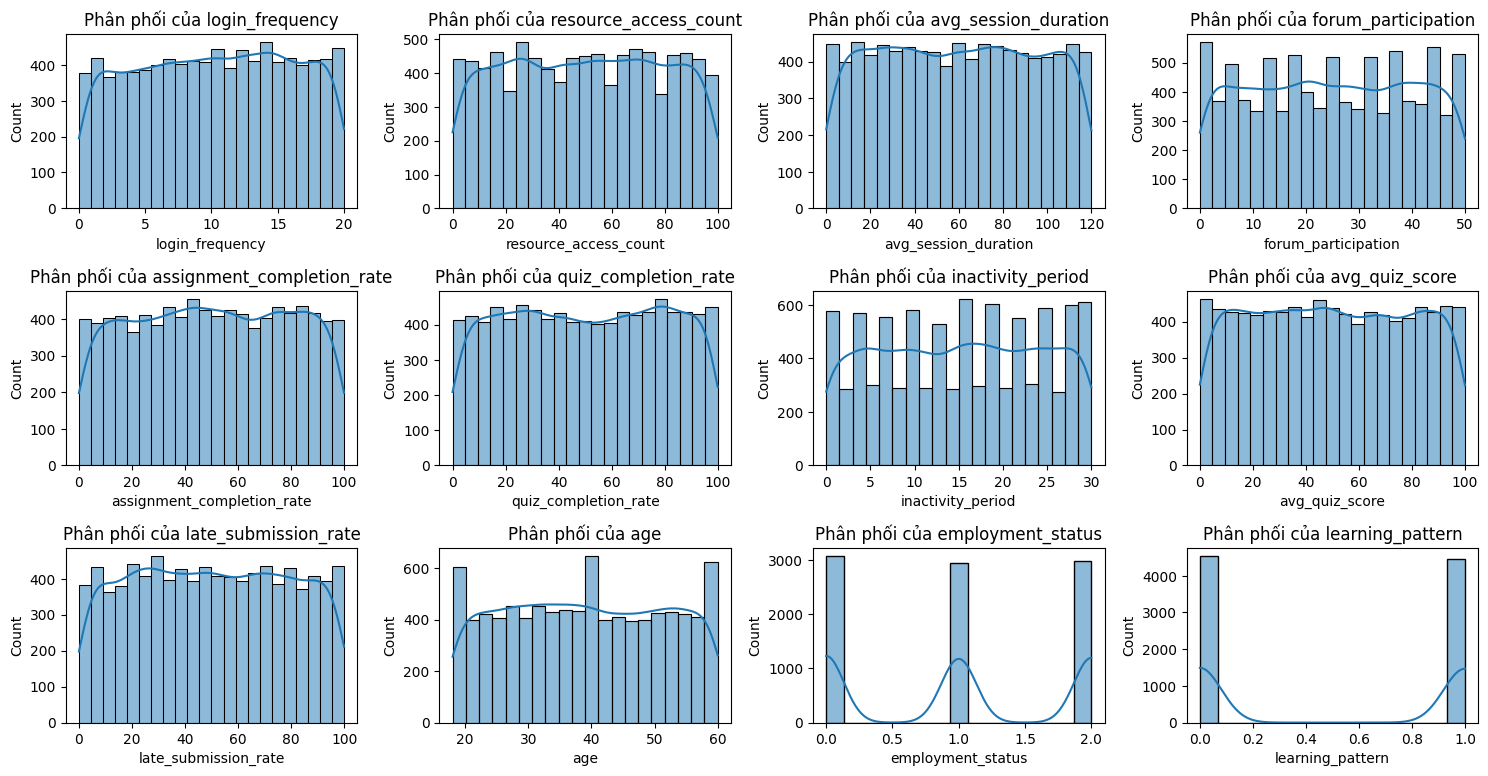

In [10]:
# Phân phối cột số (Histogram)
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(4, 4, i)
    sns.histplot(df[col], kde=True)
    plt.title(f'Phân phối của {col}')
plt.tight_layout()
plt.show()

## **MA TRẬN TƯƠNG QUAN GIỮA CÁC BIẾN**

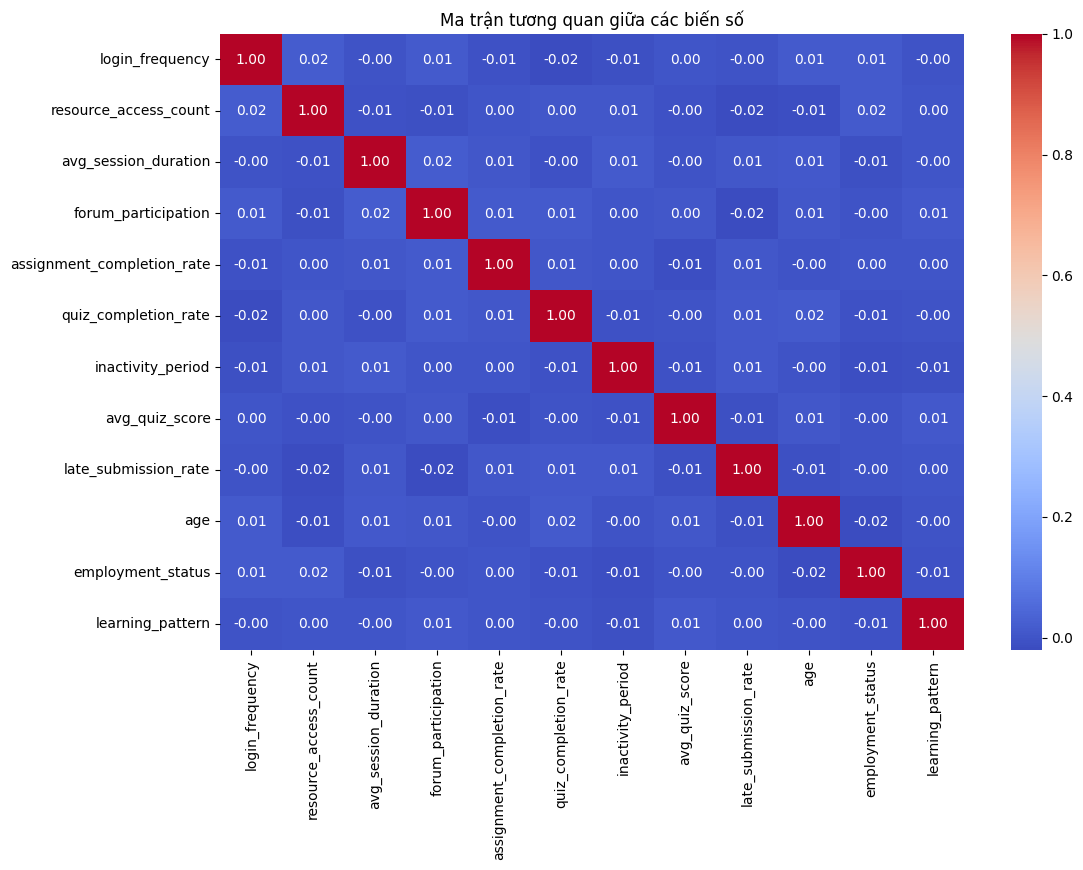

In [11]:
# Tương quan giữa các biến số
plt.figure(figsize=(12, 8))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Ma trận tương quan giữa các biến số')
plt.savefig('correlation_matrix.png')
plt.show()

## **MÃ HÓA BIẾN PHÂN LOẠI**

In [12]:
# Các biến phân loại
categorical_cols = df.select_dtypes(include=['object']).columns
print("Các biến phân loại:")
print(categorical_cols)

Các biến phân loại:
Index(['gender', 'learning_mode', 'device_type'], dtype='object')


In [13]:
# Sử dụng phương pháp dummies
df_dummies = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
df_dummies

,login_frequency,resource_access_count,avg_session_duration,forum_participation,assignment_completion_rate,quiz_completion_rate,inactivity_period,avg_quiz_score,late_submission_rate,age,employment_status,learning_pattern,dropout,gender_Male,learning_mode_Instructor-led learning,learning_mode_Self-study,device_type_Mobile phone,device_type_Tablet
0,7.448474,29,75.592809,7,70.980378,87.002316,25,76.474338,2.330537,49,1,0,0,True,False,True,False,True
1,15.798234,12,94.330348,18,89.254519,1.954311,18,61.269420,1.964830,27,2,1,0,False,False,True,True,False
2,0.786390,14,95.988471,9,69.078629,41.999831,19,8.073264,43.684065,51,2,1,1,True,False,False,False,True
3,8.635351,19,102.121509,32,41.662303,96.041406,26,11.858173,92.420582,22,0,1,1,True,False,True,False,True
4,7.645118,33,31.999654,36,51.366122,17.716174,22,48.119323,76.811934,37,0,1,1,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8995,16.087170,91,97.201884,47,86.542311,22.678546,18,42.243637,62.131962,42,0,1,0,False,False,False,False,True
8996,1.786390,19,49.773895,34,65.011714,29.074791,29,55.026489,53.700899,31,2,1,1,True,False,False,False,True
8997,17.189866,64,21.323363,39,86.751017,82.696743,18,20.955839,1.606888,48,1,1,0,False,True,False,False,True
8998,6.223134,63,91.349424,7,74.047450,94.123136,8,85.846014,56.237040,60,1,0,0,True,False,True,True,False


## **CHUẨN HÓA DỮ LIỆU**

In [14]:
# Tách cột mục tiêu ra
features = df_dummies.drop(columns=['dropout'])
target = df_dummies['dropout']

# Khởi tạo và áp dụng MinMaxScaler cho phần features
scaler = MinMaxScaler()
features_scaled = pd.DataFrame(scaler.fit_transform(features), columns=features.columns)

# Nối lại với cột mục tiêu
df_scaled = pd.concat([features_scaled, target.reset_index(drop=True)], axis=1)
df_scaled

,login_frequency,resource_access_count,avg_session_duration,forum_participation,assignment_completion_rate,quiz_completion_rate,inactivity_period,avg_quiz_score,late_submission_rate,age,employment_status,learning_pattern,gender_Male,learning_mode_Instructor-led learning,learning_mode_Self-study,device_type_Mobile phone,device_type_Tablet,dropout
0,0.372430,0.29,0.630071,0.14,0.709865,0.870108,0.833333,0.764791,0.023039,0.738095,0.5,0.0,1.0,0.0,1.0,0.0,1.0,0
1,0.789980,0.12,0.786251,0.36,0.892655,0.019499,0.600000,0.612703,0.019380,0.214286,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0
2,0.039277,0.14,0.800071,0.18,0.690842,0.420015,0.633333,0.080607,0.436813,0.785714,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1
3,0.431783,0.19,0.851191,0.64,0.416605,0.960513,0.866667,0.118466,0.924459,0.095238,0.0,1.0,1.0,0.0,1.0,0.0,1.0,1
4,0.382264,0.33,0.266716,0.72,0.513670,0.177141,0.733333,0.481169,0.768282,0.452381,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8995,0.804429,0.91,0.810185,0.94,0.865526,0.226773,0.600000,0.422397,0.621398,0.571429,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0
8996,0.089285,0.19,0.414867,0.68,0.650162,0.290745,0.966667,0.550258,0.537039,0.309524,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1
8997,0.859572,0.64,0.177728,0.78,0.867613,0.827046,0.600000,0.209465,0.015798,0.714286,0.5,1.0,0.0,1.0,0.0,0.0,1.0,0
8998,0.311154,0.63,0.761404,0.14,0.740544,0.941327,0.266667,0.858531,0.562415,1.000000,0.5,0.0,1.0,0.0,1.0,1.0,0.0,0


## **CHIA DỮ LIỆU**

In [15]:
# Tách đặc trưng và mục tiêu
X = df_scaled.drop(columns=['dropout'], axis=1)
y = df_scaled['dropout'].astype(int)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## **PHÂN PHỐI BIẾN MỤC TIÊU**

Phân phối biến mục tiêu (dropout) trong y_train:
dropout
0    4320
1    2880
Name: count, dtype: int64


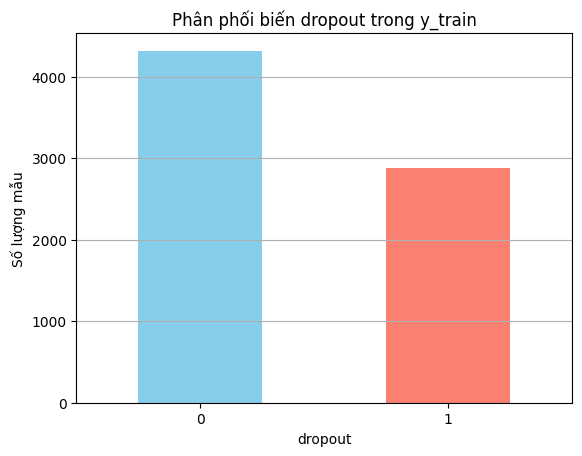

In [16]:
print("Phân phối biến mục tiêu (dropout) trong y_train:")
print(y_train.value_counts())
# Vẽ biểu đồ cột
y_train.value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Phân phối biến dropout trong y_train')
plt.xlabel('dropout')
plt.ylabel('Số lượng mẫu')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

## **XỬ LÝ MẤT CÂN BẰNG BẰNG SMOTE**

dropout
0    4320
1    4320
Name: count, dtype: int64


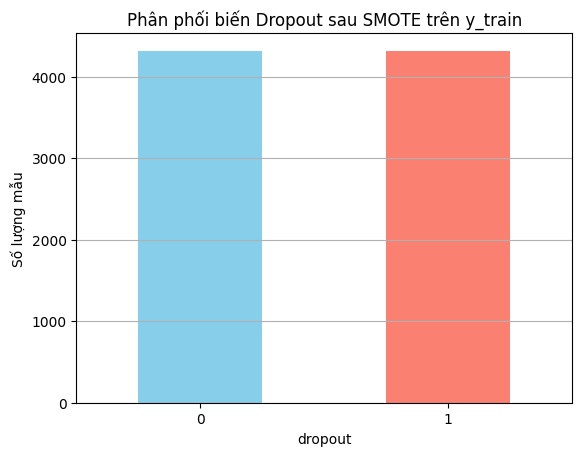

In [17]:
# Áp dụng SMOTE để tạo mẫu mới cho lớp thiểu số
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# Kiểm tra lại phân phối sau khi SMOTE
print(y_resampled.value_counts())

# Vẽ biểu đồ phân phối
y_resampled.value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Phân phối biến Dropout sau SMOTE trên y_train')
plt.xlabel('dropout')
plt.ylabel('Số lượng mẫu')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

## **TRÍCH CHỌN ĐẶC TRƯNG BẰNG RANDOM FOREST**

In [18]:
# Huấn luyện mô hình Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_resampled, y_resampled)

# Lấy importance
importances = rf.feature_importances_
features = X_resampled.columns

# Gộp lại vào DataFrame
feat_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
})
feat_importance_df = feat_importance_df.sort_values(by='Importance', ascending=False)

# In kết quả
print(feat_importance_df.head(20))

# Lọc đặc trưng quan trọng > 0.01
important_features = feat_importance_df[feat_importance_df['Importance'] > 0.01]['Feature'].tolist()

print(f"Số đặc trưng quan trọng chọn: {len(important_features)}")
print("Danh sách đặc trưng quan trọng:", important_features)

                                  Feature  Importance
0                         login_frequency    0.162145
4              assignment_completion_rate    0.157427
8                    late_submission_rate    0.155323
7                          avg_quiz_score    0.150052
5                    quiz_completion_rate    0.148076
6                       inactivity_period    0.070245
2                    avg_session_duration    0.030899
1                   resource_access_count    0.029543
9                                     age    0.028097
3                     forum_participation    0.028039
10                      employment_status    0.009281
11                       learning_pattern    0.007626
12                            gender_Male    0.005041
14               learning_mode_Self-study    0.004977
13  learning_mode_Instructor-led learning    0.004769
15               device_type_Mobile phone    0.004333
16                     device_type_Tablet    0.004127
Số đặc trưng quan trọng chọn

## **kẾT QUẢ ĐÁNH GIÁ MÔ HÌNH RANDOM FOREST**

In [29]:
# Tách đặc trưng và mục tiêu
X = df_scaled[['login_frequency', 'assignment_completion_rate', 'late_submission_rate', 'avg_quiz_score', 'quiz_completion_rate', 'inactivity_period', 'avg_session_duration', 'resource_access_count', 'age', 'forum_participation']]
y = df_scaled['dropout']

# Tách tập train-test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Huấn luyện mô hình Random Forest trên dữ liệu đã cân bằng
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Dự đoán trên tập test (chưa cân bằng)
y_pred = rf.predict(X_test)

# Đánh giá mô hình
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9388888888888889
Confusion Matrix:
 [[1047   33]
 [  77  643]]
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.97      0.95      1080
           1       0.95      0.89      0.92       720

    accuracy                           0.94      1800
   macro avg       0.94      0.93      0.94      1800
weighted avg       0.94      0.94      0.94      1800



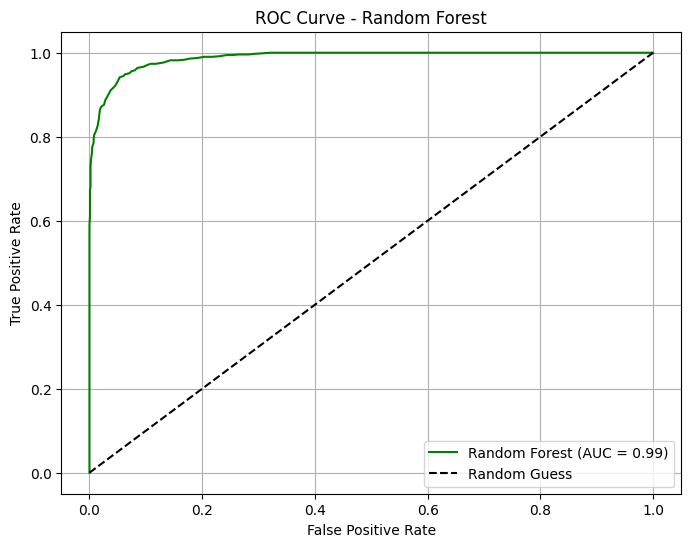

In [30]:
# Dự đoán xác suất cho lớp 1 (dropout)
y_probs_rf = rf.predict_proba(X_test)[:, 1]

# Tính FPR, TPR và AUC
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_probs_rf)
auc_rf = roc_auc_score(y_test, y_probs_rf)

# Vẽ biểu đồ ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='green', label=f'Random Forest (AUC = {auc_rf:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## **TRÍCH CHỌN ĐẶC TRƯNG BẰNG MÔ HÌNH XGBOOST**

In [20]:
# Huấn luyện mô hình XGBoost
xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_resampled, y_resampled)

# Lấy importance
importances = xgb.feature_importances_
features = X_resampled.columns

# Gộp lại vào DataFrame
feat_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
})
feat_importance_df = feat_importance_df.sort_values(by='Importance', ascending=False)

# In kết quả
print(feat_importance_df.head(20))

# Lọc đặc trưng quan trọng > 0.01
important_features = feat_importance_df[feat_importance_df['Importance'] > 0.01]['Feature'].tolist()

print(f"Số đặc trưng quan trọng chọn: {len(important_features)}")
print("Danh sách đặc trưng quan trọng:", important_features)

                                  Feature  Importance
0                         login_frequency    0.157881
8                    late_submission_rate    0.140816
4              assignment_completion_rate    0.138991
5                    quiz_completion_rate    0.134812
7                          avg_quiz_score    0.127943
6                       inactivity_period    0.094975
11                       learning_pattern    0.088576
14               learning_mode_Self-study    0.014695
3                     forum_participation    0.014212
13  learning_mode_Instructor-led learning    0.013782
9                                     age    0.012274
1                   resource_access_count    0.011492
2                    avg_session_duration    0.010852
16                     device_type_Tablet    0.010755
15               device_type_Mobile phone    0.010170
10                      employment_status    0.010022
12                            gender_Male    0.007753
Số đặc trưng quan trọng chọn

## **KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH XGBOOST**

In [27]:
# Tách đặc trưng và mục tiêu
X = df_scaled[['login_frequency', 'late_submission_rate', 'assignment_completion_rate', 'quiz_completion_rate', 'avg_quiz_score', 'inactivity_period', 'learning_pattern', 'learning_mode_Self-study', 'forum_participation', 'learning_mode_Instructor-led learning', 'age', 'resource_access_count', 'avg_session_duration', 'device_type_Tablet', 'device_type_Mobile phone', 'employment_status']]
y = df_scaled['dropout']

# Tách tập train-test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Khởi tạo mô hình XGBoost
xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

# Huấn luyện trên dữ liệu đã cân bằng
xgb.fit(X_train, y_train)

# Dự đoán trên tập test (chưa cân bằng)
y_pred = xgb.predict(X_test)

# Đánh giá mô hình
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.96
Confusion Matrix:
 [[1050   30]
 [  42  678]]
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.97      0.97      1080
           1       0.96      0.94      0.95       720

    accuracy                           0.96      1800
   macro avg       0.96      0.96      0.96      1800
weighted avg       0.96      0.96      0.96      1800



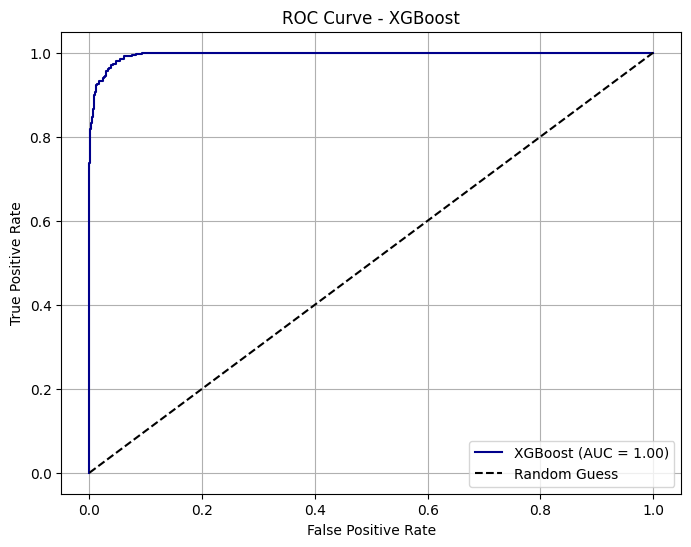

In [28]:
# Dự đoán xác suất lớp 1 (dropout)
y_probs = xgb.predict_proba(X_test)[:, 1]

# Tính các điểm FPR và TPR
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

# Tính AUC
auc_score = roc_auc_score(y_test, y_probs)

# Vẽ biểu đồ ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkblue', label=f'XGBoost (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## **TRÍCH CHỌN ĐẶC TRƯNG BẰNG MÔ HÌNH LOGISTIC REGRESSION**

In [22]:
# Huấn luyện Logistic Regression với L1 penalty để ép trọng số không quan trọng về 0
log_reg = LogisticRegression(penalty='l1', solver='liblinear', random_state=42)
log_reg.fit(X_resampled, y_resampled)

# Lấy trọng số (coefficients)
coefficients = log_reg.coef_[0]
features = X_resampled.columns

# Gộp lại vào DataFrame
feat_importance_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': coefficients
})

# Lọc ra các đặc trưng có hệ số khác 0
important_features = feat_importance_df[feat_importance_df['Coefficient'] != 0]['Feature'].tolist()

print(f"Số đặc trưng quan trọng chọn: {len(important_features)}")
print("Danh sách đặc trưng quan trọng:", important_features)

Số đặc trưng quan trọng chọn: 15
Danh sách đặc trưng quan trọng: ['login_frequency', 'resource_access_count', 'avg_session_duration', 'forum_participation', 'assignment_completion_rate', 'quiz_completion_rate', 'inactivity_period', 'avg_quiz_score', 'late_submission_rate', 'age', 'employment_status', 'learning_pattern', 'gender_Male', 'learning_mode_Instructor-led learning', 'device_type_Tablet']


## **KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH LOGISTIC REGRESSION**

In [23]:
# Tạo lại tập dữ liệu chỉ với các đặc trưng quan trọng
X = df_scaled[['login_frequency', 'resource_access_count', 'avg_session_duration', 'forum_participation', 'assignment_completion_rate', 'quiz_completion_rate', 'inactivity_period', 'avg_quiz_score', 'late_submission_rate', 'age', 'employment_status', 'learning_pattern', 'gender_Male', 'learning_mode_Instructor-led learning', 'device_type_Tablet']]
y = df_scaled['dropout']

# Tách tập train-test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Huấn luyện mô hình Logistic Regression
final_model = LogisticRegression(solver='liblinear', random_state=42)
final_model.fit(X_train, y_train)

# Dự đoán
y_pred = final_model.predict(X_test)

# Đánh giá mô hình
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.99
Confusion Matrix:
 [[1080    0]
 [  18  702]]
Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99      1080
           1       1.00      0.97      0.99       720

    accuracy                           0.99      1800
   macro avg       0.99      0.99      0.99      1800
weighted avg       0.99      0.99      0.99      1800



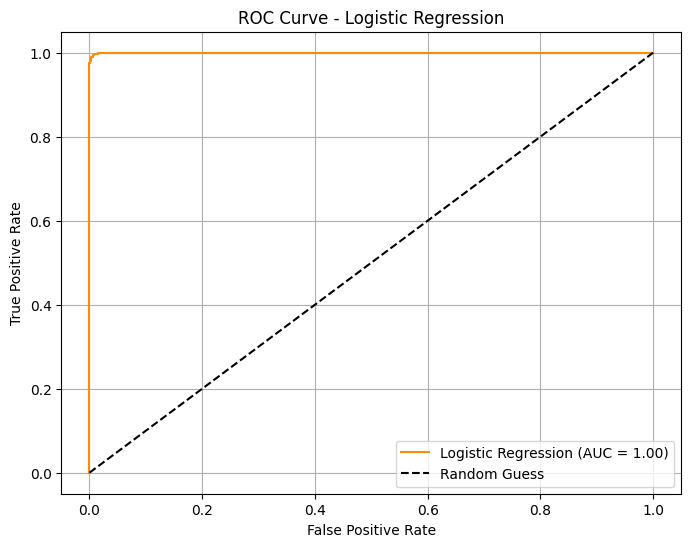

In [25]:
# Lấy xác suất dự đoán của lớp 1 (dropout)
y_probs = final_model.predict_proba(X_test)[:, 1]

# Tính FPR, TPR và thresholds cho ROC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

# Tính điểm AUC
auc_score = roc_auc_score(y_test, y_probs)

# Vẽ biểu đồ ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', label=f'Logistic Regression (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()